#  Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
import scipy.sparse as sp
import pickle
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports ready!")

✅ Imports ready!


#  Load Cleaned Data

In [2]:
df = pd.read_csv('../data/processed/emails_raw_merged.csv')

print(f"Total emails : {len(df):,}")
print(f"Columns      : {df.columns.tolist()}")
print()
print("Label distribution:")
print(df['label'].value_counts())

Total emails : 10,706
Columns      : ['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label', 'source', 'label_name']

Label distribution:
label
1    6615
0    4091
Name: count, dtype: int64


# Understand TF-IDF 

In [4]:
# max_features=5000 → keep only the 5000 most important words
# ngram_range=(1,2) → use single words AND pairs (e.g. "click here", "bank account")
# min_df=2          → ignore words that appear in fewer than 2 emails (typos/noise)
# sublinear_tf=True → apply log scaling to term frequency (reduces impact of very common words)

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

# Choose available text map column:
text_cols = [c for c in ['processed_text', 'cleaned_text', 'text', 'email', 'message', 'body'] if c in df.columns]
if not text_cols:
    raise KeyError("No text column found in df. Expected one of ['processed_text','cleaned_text','text','email','message','body']")

text_col = text_cols[0]
print(f"Using text column: {text_col}")

df[text_col] = df[text_col].fillna('').astype(str)
X_tfidf = tfidf.fit_transform(df[text_col])

print(f"TF-IDF matrix shape : {X_tfidf.shape}")
print(f"  → {X_tfidf.shape[0]:,} emails × {X_tfidf.shape[1]:,} word features")

Using text column: body
TF-IDF matrix shape : (10706, 5000)
  → 10,706 emails × 5,000 word features


# Top Words That Signal Phishing vs Legitimate

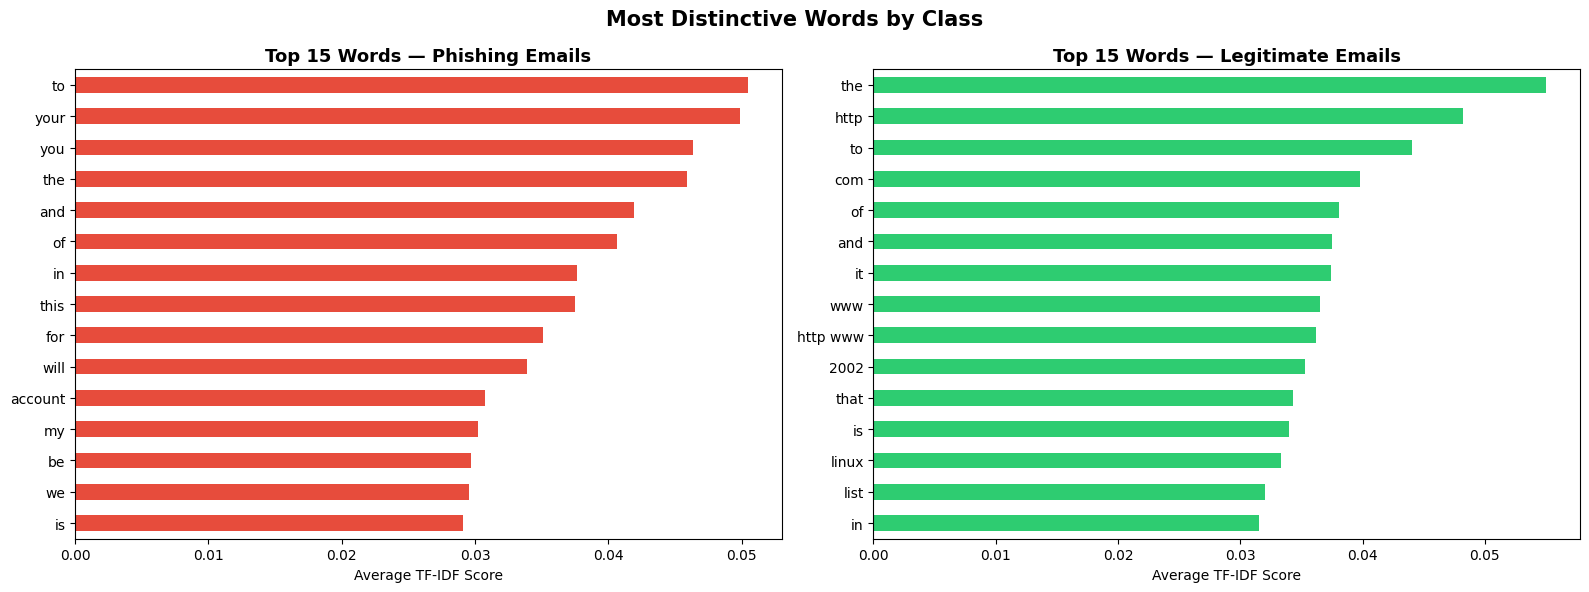

In [5]:
feature_names = tfidf.get_feature_names_out()

# Get average TF-IDF score per word for each class
phishing_idx  = df[df['label'] == 1].index
legit_idx     = df[df['label'] == 0].index

phishing_scores = np.asarray(X_tfidf[phishing_idx].mean(axis=0)).flatten()
legit_scores    = np.asarray(X_tfidf[legit_idx].mean(axis=0)).flatten()

top_phishing = pd.Series(phishing_scores, index=feature_names).nlargest(15)
top_legit    = pd.Series(legit_scores,    index=feature_names).nlargest(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_phishing.sort_values().plot(kind='barh', ax=axes[0], color='#e74c3c')
axes[0].set_title('Top 15 Words — Phishing Emails', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Average TF-IDF Score')

top_legit.sort_values().plot(kind='barh', ax=axes[1], color='#2ecc71')
axes[1].set_title('Top 15 Words — Legitimate Emails', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Average TF-IDF Score')

plt.suptitle('Most Distinctive Words by Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/tfidf_top_words.png', dpi=150)
plt.show()

#  Prepare Numerical Features

In [7]:
# These are the hand-crafted features we created in preprocessing
numerical_cols = ['word_count', 'char_count', 'unique_word_count',
                  'has_urls', 'subject_length']

# If any handcrafted columns are missing (e.g., this dataset is partial), fill with 0 to avoid KeyError
for col in numerical_cols:
    if col not in df.columns:
        print(f"⚠️  Column '{col}' missing; filling with 0")
        df[col] = 0

X_numerical = df[numerical_cols].values

# Scale numerical features (important! Random Forest doesn't need it,
# but SVM and Logistic Regression do)
scaler = StandardScaler()
X_numerical_scaled = scaler.fit_transform(X_numerical)

print(f"Numerical features shape: {X_numerical_scaled.shape}")
print(f"Features: {numerical_cols}")

⚠️  Column 'word_count' missing; filling with 0
⚠️  Column 'char_count' missing; filling with 0
⚠️  Column 'unique_word_count' missing; filling with 0
⚠️  Column 'has_urls' missing; filling with 0
⚠️  Column 'subject_length' missing; filling with 0
Numerical features shape: (10706, 5)
Features: ['word_count', 'char_count', 'unique_word_count', 'has_urls', 'subject_length']


# Combine TF-IDF + Numerical Features

In [8]:
# Convert scaled numerical array to sparse matrix so we can combine it
# with the TF-IDF sparse matrix efficiently
X_numerical_sparse = sp.csr_matrix(X_numerical_scaled)

# Stack horizontally: 5000 TF-IDF features + 5 numerical features
X_combined = sp.hstack([X_tfidf, X_numerical_sparse])

# Target variable
y = df['label'].values

print(f"Final feature matrix shape : {X_combined.shape}")
print(f"  → {X_combined.shape[0]:,} emails × {X_combined.shape[1]:,} total features")
print(f"Target shape               : {y.shape}")
print(f"Class balance: {np.bincount(y)}")

Final feature matrix shape : (10706, 5005)
  → 10,706 emails × 5,005 total features
Target shape               : (10706,)
Class balance: [4091 6615]


#  Train/Test Split

In [9]:
from sklearn.model_selection import train_test_split

# 80% training, 20% testing
# stratify=y ensures both splits have same class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training samples : {X_train.shape[0]:,}")
print(f"Testing samples  : {X_test.shape[0]:,}")
print()
print(f"Train class distribution: {np.bincount(y_train)}")
print(f"Test  class distribution: {np.bincount(y_test)}")

Training samples : 8,564
Testing samples  : 2,142

Train class distribution: [3272 5292]
Test  class distribution: [ 819 1323]


# Save Everything for Model Training

In [10]:
# Save the split data
sp.save_npz('../data/processed/X_train.npz', X_train)
sp.save_npz('../data/processed/X_test.npz',  X_test)
np.save('../data/processed/y_train.npy', y_train)
np.save('../data/processed/y_test.npy',  y_test)

# Save the fitted TF-IDF vectorizer and scaler
# We MUST use the SAME vectorizer when predicting on new emails later
with open('../models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Saved:")
print("   data/processed/X_train.npz")
print("   data/processed/X_test.npz")
print("   models/tfidf_vectorizer.pkl")
print("   models/scaler.pkl")
print()
print("🎉 Feature Engineering complete! Move to Notebook 04.")

✅ Saved:
   data/processed/X_train.npz
   data/processed/X_test.npz
   models/tfidf_vectorizer.pkl
   models/scaler.pkl

🎉 Feature Engineering complete! Move to Notebook 04.
